<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo Practico de 1er Laboratorio

Autor: Hernán Leonel Campos

#### Filtro Pedido

| Filtro | Fun. de Aprox. | Frec. de corte | Frec. de stop | Max. aten. | Min. Aten | 
| --- | --- | --- | --- | --- | --- |
| A | Chebyshev | 1.5 kHz | 4.5 kHz | 0.5 dB | 16 dB |

#### Calculos iniciales

\begin{equation}
\Omega_{w} = 2. \pi . 1.5 kHz \ \ \ \ 
w_{c} = 1 \ \ \ \
w_{s} = 3
\end{equation}
\begin{equation}
\varepsilon^{2} = 10^{\frac{\alpha max}{10}} - 1
\end{equation}
\begin{equation}
\varepsilon^{2} \approx 0.122
\end{equation}
\begin{equation}
\alpha = 10 log ( 1 + \varepsilon^{2} cosh^{2} ( n . arccosh (w_{s}) ) )
\end{equation}


| n | $ \alpha $ | ? |
|--- | --- | --- |
|1 | 3.2 dB | X |
| 2 | 15.59 dB | X |
| 3 | 30.77 dB | $\checkmark$ |

In [32]:
# Módulos externos

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [34]:
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex

In [36]:
# Comienzo de la simulación
ripple = 0.5
eps_2 = 10**(ripple/10) - 1

# Cargamos la funcion transferencia como vectores de sus coeficientes.

num = np.array([ 1 ])
den = np.array([-16*eps,0,-12*eps,0,-9*eps,0,1])

H1 = sig.TransferFunction( num, den )

# mostramos la transferencia construida
display(H1)
    

TransferFunctionContinuous(
array([-0.51229508]),
array([ 1.        , -0.        ,  0.75      , -0.        ,  0.5625    ,
       -0.        , -0.51229508]),
dt: None
)

\begin{equation}
|T(w)|^{2} = \frac{1}{1 + \varepsilon^{2}.C_{n}^{2} (w)}
\end{equation}
\begin{equation}
C_{3} = 4.w^{3} - 3.w
\end{equation}
\begin{equation}
C_{3}^{2} = 16.w^{6} - 12 . w^{4} + 9 . w^{2}
\end{equation}
\begin{equation}
|T(w)|^{2} = \frac{1}{1 + \varepsilon^{2}.(16.w^{6} - 12 . w^{4} + 9 . w^{2})}
\end{equation}
\begin{equation}
|T(s)|^{2}  = |T(w)|^2 |_{w=\frac{s}{j}}= \frac{1}{1 + \varepsilon^{2}.(-16.s^{6} - 12 . s^{4} - 9 . s^{2})}
\end{equation}
\begin{equation}
|T(s)|^{2}  = |T(w)|^2 |_{w=\frac{s}{j}}= \frac{1}{-16.\varepsilon^{2}.s^{6} - 12 .\varepsilon^{2} . s^{4} - 9 . \varepsilon^{2} . s^{2} + 1}
\end{equation}

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

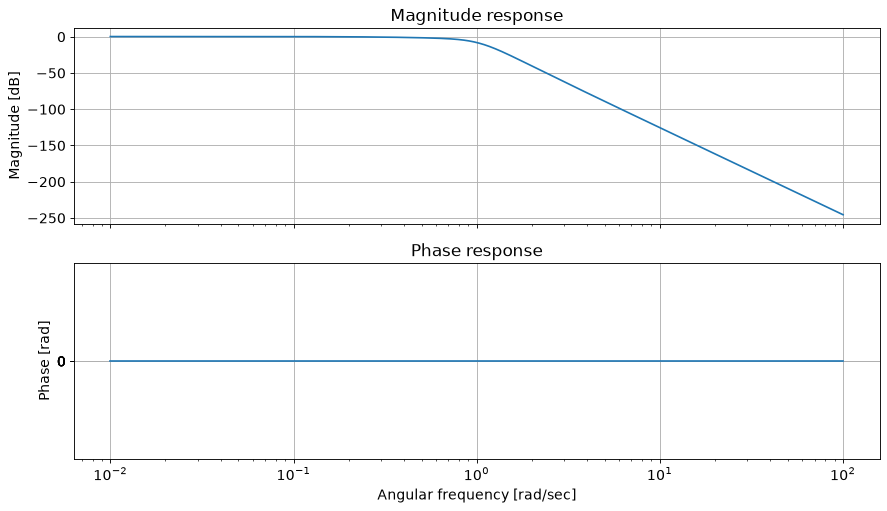

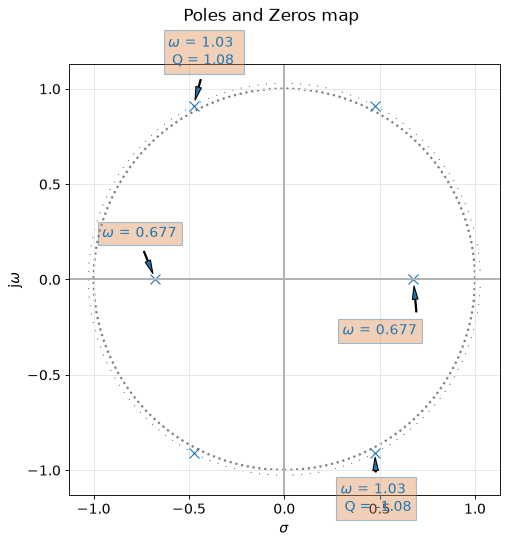

In [41]:
_, axes_hdl = bodePlot(H1)

plt.sca(axes_hdl[0])

pzmap(H1, annotations = True)



Con el $|T_{(s)}|^{2}$ conseguido, este se puede descomponer en $|T_{(s)}| * |T_{(-s)}|$ correspondientemente en los polos del semi-plano izquierdo y el semi-plano derecho. E ignorando el resultante del semi-plano derecho. Nos quedan los tres polos correspondientes al filtro pedido normalizado.

$|T_{(s)}| = \frac{0.7156}{s^{3}+s^{2}.1.6285+s.1.7009+0.7156} = \frac{0.677}{s+0.677} . \frac{1.0567}{s^{2}+s.0.9513+1.0567} = \frac{0.677}{s+0.677} . \frac{1.028^{2}}{s^{2}+s.\frac{1.028}{1.081}+1.028^{2}}  $

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

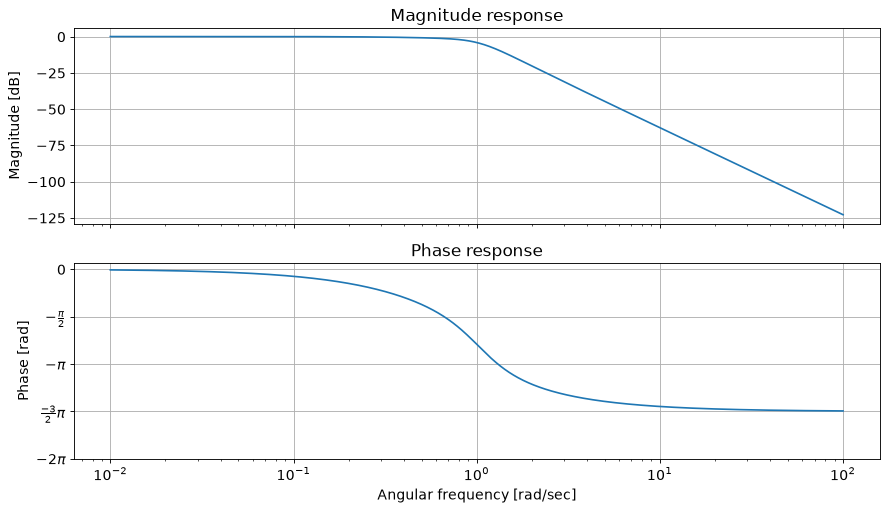

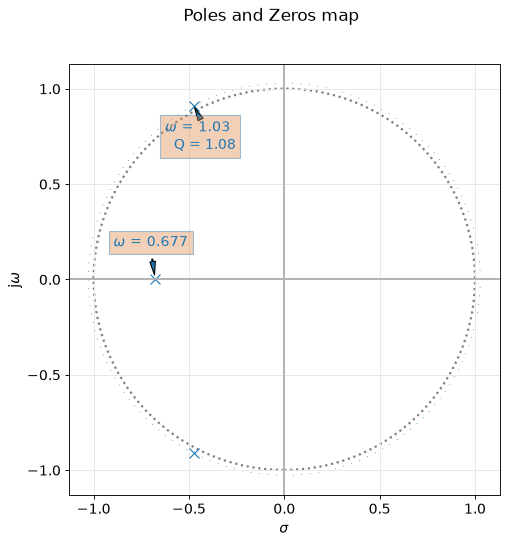

In [49]:
num = np.array([ 0.715658422 ])
den = np.array([1,1.6285655,1.700980587,0.715658422])
H1 = sig.TransferFunction( num, den )

_, axes_hdl = bodePlot(H1)

plt.sca(axes_hdl[0])

pzmap(H1, annotations = True)


A partir de los polos se puede armar el circuito.
Ya que el Q del par conjugado es bajo, se decidio usar un sallen-key sin ganancia.

Primera etapa: 

w1 = 1.028

Q1= 1.081


Segunda Etapa: 

w2= 0.677

#### Simulacion

<img src="./Completo.PNG" width="600" /> 

Circuito Completo con valores comerciales

<img src="./1-5khz.PNG" width="450" /> 
Atenuacion a 1.5khz = 0.44 dB
<img src="./4-5khz.PNG" width="450" /> 
Atenuacion a 4.5khz = -24 dB

<img src="./Simulacion.PNG" width="900" /> 
Grafico de simulacion completo

### Practica

<img src="./Model.jpeg" width="300" /> 
Modelo de la placa utilizada

<img src="./Circuit.jpeg" width="300" /> 

Datos obtenidos en la practica:

frec (Hz)|	Vin pp|	Vout pp|	Amp (veces)|	Aten (dB)|	∆T	|Fase (°)|
--- | --- | ---| --- |--- |---| --- |
50	|3|	3.07|	1.023333333	|0.2003424152	|0.00003|	-0.54|
200|	3	|3	|1	|0	|0.000228|	-16.416|
500	|3.03|	2.74	|0.904290429|	-0.8738413136|	0.0002	|-36|
800|	3.03|	2.55|	0.8415841584|	-1.498048961|	0.000186|	-53.568|
1000|	3.03|	2.51|	0.8283828383	|-1.63537814|	0.000178|	-64.08|
1200	|3.03	|2.55|	0.8415841584|	-1.498048961|	0.000172|-74.304|
1500	|3.03	|2.64|	0.8712871287	|-1.196774033|	0.00017|	-91.8|
1800|	3|	2.79|	0.93	|-0.6303410289|	0.00018|	-116.64|
2000|3.03|	2.74|	0.904290429|	-0.8738413136|	0.000198	|-142.56|
2200	|2.92|	2.4|	0.8219178082|	-1.703432195|	0.000212|	-167.904|
2500	|2.92	|1.58|	0.5410958904|	-5.33451529|	0.00021	|-189|
2700	|2.92	|1.2	|0.4109589041|	-7.724032108|	0.000216|	-209.952|
3000	|2.92	|0.768|	0.2630136986|	-11.60043263|	0.000206	|-222.48|
3500	|2.92|	0.44	|0.1506849315|	-16.4386035|	0.000186	|-234.36|
4000	|2.92|	0.268|	0.09178082192|	-20.74496115|	0.000168	|-241.92|
4500	|2.92|	0.18	|0.06164383562	|-24.20220693|	0.000148	|-239.76|
5500|	2.92|	0.092|	0.03150684932	|-30.03190048|	0.000124|	-245.52|
6500	|2.92|	0.056|	0.01917808219	|-34.34389649|	0.00011|	-257.4|
8500	|2.92|	0.024|	0.008219178082	|-41.70343219	|0.000084|-257.04|
10500|	2.92|	0.013	|0.004452054795|	-47.02878998|	0.000068|	-257.04|
15500|	2.92	|0.005|	0.001712328767|	-55.32825694	|0.000048	|-267.84|

<img src="./Amplitud.PNG" width="600" /> 
Grafica de la amplitud, segun los datos obtenidos en la practica, con dB en el eje vertical, y log(frec) en el eje horizontal.
(log(frec) es para que se vea en referencia a los datos obtenidos en la simulacion)

<img src="./Fase.PNG" width="600" /> 
Grafica de la Fase, con ° en el eje vertical, y log(frec) en el eje horizontal.

### Conclusión

Lo visto en la practica se asemeja mucho a lo visto en la teoria y en las simulaciones.